In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, ConfusionMatrixDisplay)

df = pd.read_csv("Dataset.csv")
df = df.drop_duplicates(subset="title").reset_index(drop=True)
print(df.shape)
df.head()

(8787, 10)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


Movie      6124
TV Show    2663
Name: type, dtype: int64

Majority-class baseline accuracy: 0.697


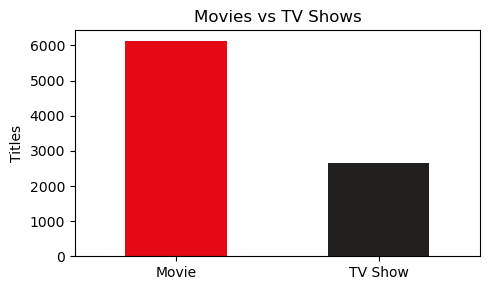

In [3]:
counts = df["type"].value_counts()
print(counts)
print("\nMajority-class baseline accuracy:", round(counts.max() / counts.sum(), 3))
counts.plot(kind="bar", color=["#e50914", "#221f1f"], figsize=(5, 3))
plt.title("Movies vs TV Shows"); plt.xticks(rotation=0); plt.ylabel("Titles")
plt.tight_layout(); plt.show()

The data is **imbalanced** (about 70% Movies). A model that always says "Movie" would already score ~70%, so that is the number we must beat. We will also look at precision, recall and F1, not only accuracy.

In [ ]:
y = (df["type"] == "TV Show").astype(int)

# CHECK FOR DATA LEAKAGE: does any column give the answer away?
df["duration_unit"] = df["duration"].str.extract(r"([A-Za-z]+)")[0]
print(pd.crosstab(df["duration_unit"], df["type"]))

type           Movie  TV Show
duration_unit                
Season             0     1790
Seasons            0      873
min             6124        0


In [5]:
X_leak = pd.get_dummies(df["duration_unit"])
a, b, c, d = train_test_split(X_leak, y, test_size=0.2, stratify=y, random_state=42)
leaky = DecisionTreeClassifier(max_depth=2, random_state=42).fit(a, c)
print("Accuracy using ONLY duration:", accuracy_score(d, leaky.predict(b)))

Accuracy using ONLY duration: 1.0


In [ ]:
def clean_genre(g):
    g = re.sub(r"\b(TV|Shows?|Movies?)\b", "", g).strip(" '")
    return re.sub(r"\s+", " ", g).strip().lower()

genres = df["listed_in"].apply(
    lambda s: [t for t in (clean_genre(x) for x in s.split(",")) if t])
mlb = MultiLabelBinarizer()
G = pd.DataFrame(mlb.fit_transform(genres), columns=["genre_" + c for c in mlb.classes_])
print(len(mlb.classes_), "genres:", list(mlb.classes_))

32 genres: ['action & adventure', 'anime features', 'anime series', 'british', 'children & family', 'classic', 'classic & cult', 'comedies', 'crime', 'cult', 'documentaries', 'docuseries', 'dramas', 'faith & spirituality', 'horror', 'independent', 'international', 'kids', 'korean', 'lgbtq', 'music & musicals', 'mysteries', 'reality', 'romantic', 'sci-fi & fantasy', 'science & nature', 'spanish-language', 'sports', 'stand-up comedy', 'stand-up comedy & talk', 'teen', 'thrillers']


In [ ]:
added = pd.to_datetime(df["date_added"].str.strip(), format="%m/%d/%Y", errors="coerce")
X_num = pd.DataFrame({
    "release_year": df["release_year"],
    "year_added":   added.dt.year,
    "month_added":  added.dt.month,
})
X_num["years_to_netflix"] = X_num["year_added"] - X_num["release_year"]
X_num["has_director"]  = (df["director"] != "Not Given").astype(int)   # missing director is informative
X_num["has_country"]   = (df["country"] != "Not Given").astype(int)
X_num["n_countries"]   = df["country"].apply(lambda s: 0 if s == "Not Given" else len(s.split(",")))
X_num["n_genres"]      = genres.apply(len)
X_num = X_num.fillna(X_num.median())

# --- Categorical: one-hot encode rating and top-15 countries ---
R = pd.get_dummies(df["rating"], prefix="rating")
top_countries = df["country"].value_counts().head(15).index
C = pd.get_dummies(df["country"].where(df["country"].isin(top_countries), "Other"), prefix="country")

X = pd.concat([X_num, R, C, G], axis=1).astype(float)
print("Feature matrix:", X.shape)
X.head(3)

Feature matrix: (8787, 70)


,release_year,year_added,month_added,years_to_netflix,has_director,has_country,n_countries,n_genres,rating_G,rating_NC-17,...,genre_reality,genre_romantic,genre_sci-fi & fantasy,genre_science & nature,genre_spanish-language,genre_sports,genre_stand-up comedy,genre_stand-up comedy & talk,genre_teen,genre_thrillers
0,2020.0,2021.0,9.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2021.0,2021.0,9.0,0.0,1.0,1.0,1.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2021.0,2021.0,9.0,0.0,1.0,1.0,1.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)   # stratify keeps the 70/30 ratio in both sets
print("Train:", X_train.shape, " Test:", X_test.shape)

models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced")),
    "Decision Tree":       DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1),
    "Gradient Boosting":   HistGradientBoostingClassifier(random_state=42),
}
for name, m in models.items():
    m.fit(X_train, y_train)
    print("trained:", name)

Train: (7029, 70)  Test: (1758, 70)
trained: Logistic Regression
trained: Decision Tree
trained: Random Forest
trained: Gradient Boosting


In [9]:
rows = []
for name, m in models.items():
    pred = m.predict(X_test)
    rows.append({
        "Model": name,
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall":    recall_score(y_test, pred),
        "F1":        f1_score(y_test, pred),
    })
results = pd.DataFrame(rows).set_index("Model").round(4)
results

,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.9886,0.9794,0.9831,0.9813
Decision Tree,0.9841,0.9810,0.9662,0.9735
Random Forest,0.9875,0.9812,0.9775,0.9793
Gradient Boosting,0.9869,0.9775,0.9794,0.9784


Best model by F1: Logistic Regression 

              precision    recall  f1-score   support

       Movie       0.99      0.99      0.99      1225
     TV Show       0.98      0.98      0.98       533

    accuracy                           0.99      1758
   macro avg       0.99      0.99      0.99      1758
weighted avg       0.99      0.99      0.99      1758



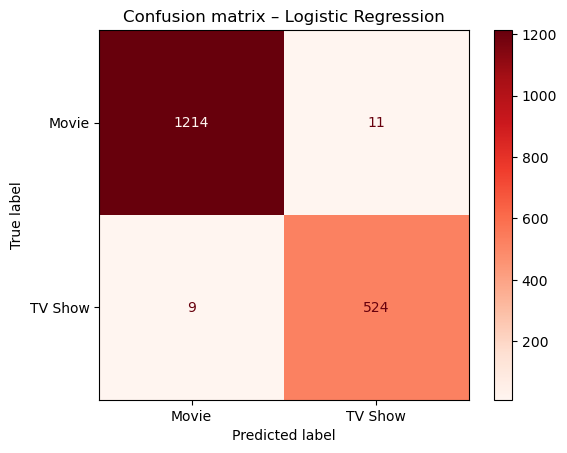

In [10]:
best_name = results["F1"].idxmax()
best = models[best_name]
pred = best.predict(X_test)
print("Best model by F1:", best_name, "\n")
print(classification_report(y_test, pred, target_names=["Movie", "TV Show"]))

ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Movie", "TV Show"], cmap="Reds")
plt.title(f"Confusion matrix – {best_name}")
plt.show()

In [11]:
# 5-fold cross-validation gives a more reliable accuracy than one single split
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = {name: cross_val_score(m, X, y, cv=cv, scoring="accuracy")
             for name, m in models.items()}
cv_table = pd.DataFrame({
    "Test accuracy": results["Accuracy"],
    "CV mean accuracy": {k: v.mean() for k, v in cv_scores.items()},
    "CV std": {k: v.std() for k, v in cv_scores.items()},
}).round(4)
cv_table

,Test accuracy,CV mean accuracy,CV std
Logistic Regression,0.9886,0.9892,0.0024
Decision Tree,0.9841,0.9859,0.0017
Random Forest,0.9875,0.9870,0.0014
Gradient Boosting,0.9869,0.9884,0.0017


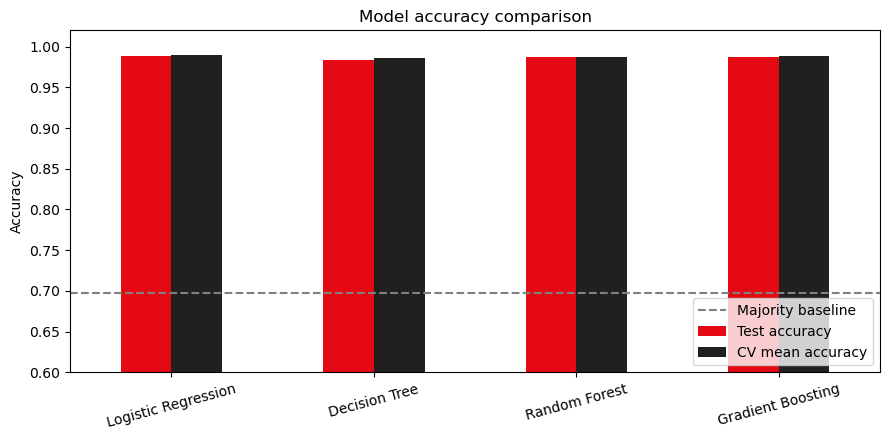

In [12]:
ax = cv_table[["Test accuracy", "CV mean accuracy"]].plot(
    kind="bar", figsize=(9, 4.5), color=["#e50914", "#221f1f"])
ax.axhline(counts.max() / counts.sum(), color="gray", linestyle="--", label="Majority baseline")
ax.set_ylim(0.6, 1.02); ax.set_ylabel("Accuracy"); ax.legend(loc="lower right")
plt.title("Model accuracy comparison"); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

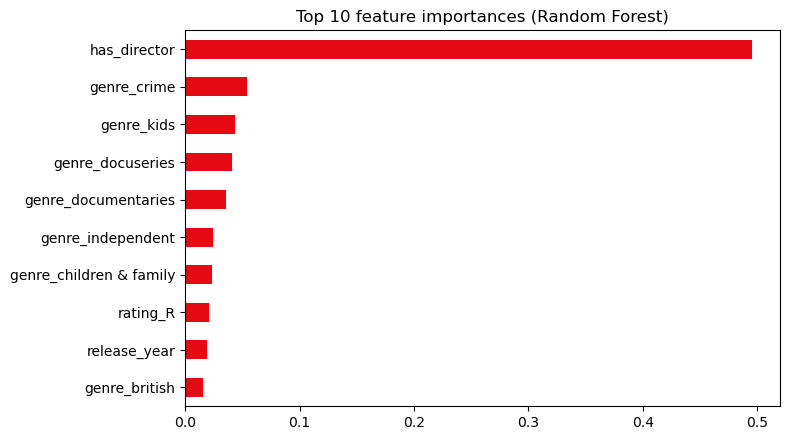

In [ ]:
imp = pd.Series(models["Random Forest"].feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
imp[::-1].plot(kind="barh", figsize=(8, 4.5), color="#e50914")
plt.title("Top 10 feature importances (Random Forest)")
plt.tight_layout(); plt.show()